# **Graph Workflows**

## **What's Covered?**
1. Conditional Graph

## **Conditional Graph**

In [1]:
# Step 1: Defining a State
from typing import TypedDict, Literal

class TaxState(TypedDict):
    # INPUTS
    income: float
    regime: str  # "new" or "old"
    
    # OUTPUTS
    tax_payable: float
    calculation_log: str  # To explain how we got the number

In [2]:
# Step 2: Defining graph nodes
def new_regime_node(state: TaxState):
    income = state["income"]
    tax = 0.0
    
    # Standard Deduction for New Regime
    taxable_income = max(0, income - 75000)
    
    # Logic: 0-3L Nil, 3-7L 5%, 7-10L 10%, 10-12L 15%, 12-15L 20%, >15L 30%
    if taxable_income <= 300000:
        tax = 0
    elif taxable_income <= 700000:
        tax = (taxable_income - 300000) * 0.05
    elif taxable_income <= 1000000:
        tax = (400000 * 0.05) + (taxable_income - 700000) * 0.10
    elif taxable_income <= 1200000:
        tax = (400000 * 0.05) + (300000 * 0.10) + (taxable_income - 1000000) * 0.15
    elif taxable_income <= 1500000:
        tax = (400000 * 0.05) + (300000 * 0.10) + (200000 * 0.15) + (taxable_income - 1200000) * 0.20
    else:
        # Complex calculation for >15L
        tax = (400000 * 0.05) + (300000 * 0.10) + (200000 * 0.15) + (300000 * 0.20) + (taxable_income - 1500000) * 0.30

    return {
        "tax_payable": tax, 
        "calculation_log": f"Calculated using NEW Regime (Standard Deduction applied). Taxable Income: {taxable_income}"
    }

In [3]:
def old_regime_node(state: TaxState):
    income = state["income"]
    tax = 0.0
    
    # Assumption: User claims typical 80C/80D deductions approx 1.5L for this simplified example
    # In a real app, we would take these as inputs.
    taxable_income = max(0, income - 150000 - 50000) # 80C + Std Ded
    
    # Logic: 0-2.5L Nil, 2.5-5L 5%, 5-10L 20%, >10L 30%
    if taxable_income <= 250000:
        tax = 0
    elif taxable_income <= 500000:
        tax = (taxable_income - 250000) * 0.05
    elif taxable_income <= 1000000:
        tax = (250000 * 0.05) + (taxable_income - 500000) * 0.20
    else:
        tax = (250000 * 0.05) + (500000 * 0.20) + (taxable_income - 1000000) * 0.30

    return {
        "tax_payable": tax, 
        "calculation_log": f"Calculated using OLD Regime (80C+Std Ded applied). Taxable Income: {taxable_income}"
    }

## **Way 1: Using add_conditional_edges**

If you want to use `add_conditional_edges`, your function must return a string (the node name).

**Syntax**
```python
graph.add_conditional_edges(
    source_node, 
    routing_function, 
    path_map=None
)
```
- **source_node (str):** The name of the node that, once finished, will trigger this routing logic.
- **routing_function (Callable):** A function that takes the current State as input and returns a value (typically a str or a list of strs representing the next node name).
- **path_map (dict, optional):** A mapping that connects the output of your routing_function to specific node names. If you omit this, LangGraph assumes the output of your routing function is the name of the next node.


**Important Consideration:** When using add_conditional_edges, LangGraph automatically generates the edge labels in your Mermaid visualization based on the keys in your path_map

In [4]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(TaxState)

graph.add_node("new_regime_node", new_regime_node)
graph.add_node("old_regime_node", old_regime_node)

# The Conditional Logic
def route_tax_regime(state: TaxState) -> str:
    # Simply check the user's string input
    choice = state["regime"].lower().strip()
    return choice


graph.add_conditional_edges(
    START,              # From the start...
    route_tax_regime,    # ...run this function to decide where to go
    {
        "new": "new_regime_node",   # If "new", go to "new_regime_node"
        "old": "old_regime_node"    # If "old", go to "old_regime_node"
    }
)

graph.add_edge("new_regime_node", END)
graph.add_edge("old_regime_node", END)

# Step 4: Compile the graph
workflow = graph.compile()

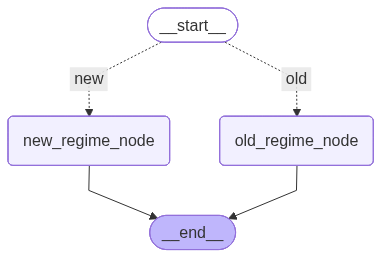

In [5]:
# Visualize the Graph

from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

## **Way 2: Direct Mapping (No path_map)**

If your routing function returns the exact node name, you don't need the third argument.

**Another Consideration:** Always use `Literal` in your routers
- It explicitly tells the Python interpreter (and your code editor) that this function can only return either the string "new_regime" or the string "old_regime".
- Improving Type Safety.

In [6]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(TaxState)

graph.add_node("new_regime", new_regime_node)
graph.add_node("old_regime", old_regime_node)

# The Conditional Logic
def route_tax_regime(state: TaxState) -> Literal["new_regime", "old_regime"]:
    # Simply check the user's string input
    choice = state["regime"].lower().strip()
    
    return "new_regime" if choice=="new" else "old_regime"


graph.add_conditional_edges(
    START,              # From the start...
    route_tax_regime    # ...run this function to decide where to go
)

graph.add_edge("new_regime", END)
graph.add_edge("old_regime", END)

# Step 4: Compile the graph
workflow = graph.compile()

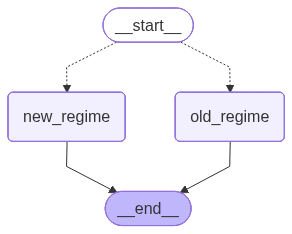

In [7]:
# Visualize the Graph

from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

## **Way 3: Command**

Command is a versatile primitive for controlling graph execution. It accepts four parameters:
- **update**: Apply state updates (similar to returning updates from a node).
- **goto**: Navigate to specific nodes (similar to conditional edges).
- **graph**: Target a parent graph when navigating from subgraphs.
- **resume**: Provide a value to resume execution after an interrupt.

Command is a powerful primitive in LangGraph that allows you to simultaneously update the state AND navigate to a specific node, bypassing the need for separate add_edge or conditional_edge logic in certain scenarios.

```python
# Utility: Update the State and Navigate to specific node
def my_node(state: State) -> Command[Literal["my_other_node"]]:
    return Command(
        # state update
        update={"foo": "bar"},
        # control flow
        goto="my_other_node"
    )


In [8]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command

graph = StateGraph(TaxState)

graph.add_node("new_regime", new_regime_node)
graph.add_node("old_regime", old_regime_node)

# The Conditional Logic
def route_tax_regime(state: TaxState) -> Command[Literal["new_regime", "old_regime"]]:
    # Simply check the user's string input
    choice = state["regime"].lower().strip()
    return Command(
        goto="new_regime" if choice=="new" else "old_regime"
    )

graph.add_node("router", route_tax_regime)

# 3. Connect START to the router node
graph.add_edge(START, "router")
graph.add_edge("new_regime", END)
graph.add_edge("old_regime", END)

# Step 4: Compile the graph
workflow = graph.compile()

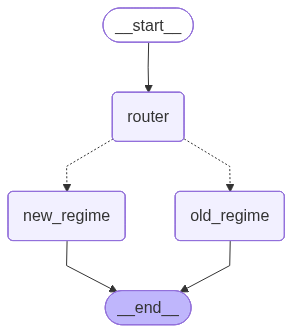

In [9]:
# Visualize the Graph

from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

In [10]:
workflow.invoke({"income": 1200000, "regime": "new"})

{'income': 1200000,
 'regime': 'new',
 'tax_payable': 68750.0,
 'calculation_log': 'Calculated using NEW Regime (Standard Deduction applied). Taxable Income: 1125000'}

In [11]:
workflow.invoke({"income": 1200000, "regime": "old"})

{'income': 1200000,
 'regime': 'old',
 'tax_payable': 112500.0,
 'calculation_log': 'Calculated using OLD Regime (80C+Std Ded applied). Taxable Income: 1000000'}

## **Example**

Smart Customer Support Triage

The Workflow Logic

    Input: A raw customer email.

    Node 1 (The Triage Agent): An LLM reads the email and categorizes it (Refund vs. Technical vs. General).

    Router: Checks the category and sends it to the correct department.

    Node 2 (The Specialist): A specialized LLM drafts the response.

        Refund Agent: Empathetic, asks for Order ID.

        Tech Agent: Analytical, asks for logs/screenshots.

        General Agent: Friendly, provides links.

In [ ]:
from typing import TypedDict, Literal
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, START, END

# Initialize LLM
llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)

# --- PROMPT 1: THE CLASSIFIER ---
# It must return EXACTLY one of these strings.
triage_prompt = ChatPromptTemplate.from_template(
    """You are a Support Triage Bot. Analyze this ticket:
    "{ticket}"
    
    Classify it into one of these three categories:
    - REFUND (If user asks for money back or is angry about billing)
    - TECH (If user has bugs, crashes, or login issues)
    - GENERAL (For pricing, feature questions, or "how to")
    
    Return ONLY the category name. Do not add punctuation."""
)
triage_chain = triage_prompt | llm | StrOutputParser()

# --- PROMPT 2: THE SPECIALISTS ---
refund_prompt = ChatPromptTemplate.from_template(
    "You are a Billing Support Agent. Write a polite, empathetic response to this angry user: {ticket}. Ask for their Order ID."
)
tech_prompt = ChatPromptTemplate.from_template(
    "You are a Technical Engineer. Analyze this bug report: {ticket}. Ask for their OS version and Console Logs. Be concise."
)
general_prompt = ChatPromptTemplate.from_template(
    "You are a General Info Bot. Answer this query cheerily: {ticket}. Refer them to help.example.com."
)

# Chains
refund_chain = refund_prompt | llm | StrOutputParser()
tech_chain = tech_prompt | llm | StrOutputParser()
general_chain = general_prompt | llm | StrOutputParser()

In [ ]:
class SupportState(TypedDict):
    ticket: str         # Input
    category: str       # Determined by Triage Node
    response: str       # Final Output

# --- NODE 1: TRIAGE ---
def triage_node(state: SupportState):
    ticket = state["ticket"]
    # Run the classification chain
    category = triage_chain.invoke({"ticket": ticket})
    
    # Clean up output just in case (remove spaces/newlines)
    clean_category = category.strip().upper()
    print(f"   [Triage] Ticket classified as: {clean_category}")
    
    return {"category": clean_category}

# --- NODE 2: SPECIALISTS ---
def handle_refund(state: SupportState):
    print("   [Refund Agent] Processing billing request...")
    res = refund_chain.invoke({"ticket": state["ticket"]})
    return {"response": res}

def handle_tech(state: SupportState):
    print("   [Tech Support] Debugging issue...")
    res = tech_chain.invoke({"ticket": state["ticket"]})
    return {"response": res}

def handle_general(state: SupportState):
    print("   [General Info] Answering query...")
    res = general_chain.invoke({"ticket": state["ticket"]})
    return {"response": res}

In [ ]:
def route_ticket(state: SupportState) -> Literal["handle_refund", "handle_tech", "handle_general"]:
    cat = state["category"]
    
    if "REFUND" in cat:
        return "handle_refund"
    elif "TECH" in cat:
        return "handle_tech"
    else:
        return "handle_general"

In [ ]:
builder = StateGraph(SupportState)

# Add Nodes
builder.add_node("triage", triage_node)
builder.add_node("handle_refund", handle_refund)
builder.add_node("handle_tech", handle_tech)
builder.add_node("handle_general", handle_general)

# Start -> Triage
builder.add_edge(START, "triage")

# Conditional Edge
builder.add_conditional_edges(
    "triage",        # Source
    route_ticket     # Logic Function
)

# All specialists go to End
builder.add_edge("handle_refund", END)
builder.add_edge("handle_tech", END)
builder.add_edge("handle_general", END)

app = builder.compile()

In [ ]:
email = "I hate this software! It charged me twice! Give me my money back now!"
result = app.invoke({"ticket": email})
print(f"\nFINAL REPLY:\n{result['response']}")

In [ ]:
email = "My app crashes whenever I try to upload a PDF file."
result = app.invoke({"ticket": email})
print(f"\nFINAL REPLY:\n{result['response']}")